# 02 — Modeling Results, Error Analysis, and Interpretation

This notebook consolidates the forecasting results generated by the training scripts.

The goals are to:
- compare baseline performance against the machine learning model,
- evaluate the contribution of the predefined feature blocks,
- inspect permutation importance for the best tuned configuration,
- analyze prediction error behavior,
- and summarize the key modeling findings in a concise, presentation-ready format.

## Why this notebook matters

This notebook consolidates the final evaluation stage of the project.  
The idea is simple: compare the main forecasting strategies under a time-aware setup, explain the key design choices, and make the final model selection transparent.

The notebook covers:
- baseline performance,
- Random Forest comparison across feature blocks,
- HistGradientBoosting as an additional benchmark,
- time-aware hyperparameter tuning,
- permutation importance,
- residual and geographic error analysis,
- and the final model decision.


## 1. Load model outputs and evaluation design

This notebook consolidates the final modeling outputs and explains how the comparison was structured.

Two design choices are especially important for coherence:

1. **Chronological train/test split (80% train, 20% test):** the project uses a global time-based split instead of a random split because the task is forecasting. Keeping the most recent portion of the data as a holdout set makes the evaluation more realistic for a time-dependent problem.An 80/20 chronological split was adopted to preserve temporal ordering while keeping a sufficiently large holdout set for reliable out-of-sample evaluation. Given the size of the dataset, this ratio provided a good balance between training capacity and test robustness.

2. **RandomizedSearchCV with TimeSeriesSplit:** hyperparameter tuning was performed with a time-aware cross-validation strategy. A randomized search was preferred over an exhaustive grid search because it provides a strong trade-off between computational efficiency and parameter exploration in a moderately large tabular problem.

The model comparison was organized in three layers:
- strong persistence-based baselines,
- Random Forest across structured feature blocks,
- HistGradientBoosting as an additional tabular benchmark under the same validation strategy.


In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")

baseline_results = pd.read_csv("../reports/baseline_metrics.csv")
ml_results = pd.read_csv("../reports/ml_results.csv")
importance_df = pd.read_csv("../reports/ml_feature_importance.csv")
ml_predictions = pd.read_parquet("../reports/ml_predictions.parquet")

hgb_results = pd.read_csv("../reports/hgb_results.csv")
hgb_predictions = pd.read_parquet("../reports/hgb_predictions.parquet")
hgb_importance_df = pd.read_csv("../reports/hgb_feature_importance.csv")

feature_candidates = [
    "../data/processed/weather_features.parquet",
    "../data/processed/GlobalWeatherRepository_features.parquet",
]
feature_path = next((p for p in feature_candidates if os.path.exists(p)), None)

if feature_path is None:
    raise FileNotFoundError("Could not find the engineered feature dataset inside ../data/processed/.")

feature_df = pd.read_parquet(feature_path)

baseline_results = baseline_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
ml_results = ml_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
importance_df = importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)

hgb_results = hgb_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
hgb_importance_df = hgb_importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)

baseline_results.head(), ml_results.head(), hgb_results.head()

(              model       mae      rmse        r2       mape
 0  last_observation  1.851315  2.725922  0.940315  55.886455
 1    rolling_mean_3  2.153061  3.120490  0.921786  69.991565
 2       naive_lag_1  2.297220  3.362395  0.909189  72.557792
 3       naive_lag_2  2.475494  3.602066  0.895782  80.603152
 4       naive_lag_3  2.548230  3.702112  0.889913  80.783772,
                         feature_set  n_features                        model  \
 0  C_temporal_meteorology_geography          29  RandomForestRegressor_tuned   
 1  C_temporal_meteorology_geography          29        RandomForestRegressor   
 2            B_temporal_meteorology          27        RandomForestRegressor   
 3                            D_full          37        RandomForestRegressor   
 4                   A_temporal_core          18        RandomForestRegressor   
 
         mae      rmse        r2       mape  \
 0  1.743873  2.528803  0.948608  56.549117   
 1  1.754461  2.553303  0.947607  55.453987  

## 2. Executive summary table

Start with the most important decision-oriented comparison:
1. the best baseline,
2. the best untuned Random Forest configuration,
3. the best tuned Random Forest configuration,
4. the best tuned HistGradientBoosting configuration.

This gives the evaluator a compact view of the full model-selection path before moving into detailed plots and diagnostics.


In [36]:
best_baseline = baseline_results.iloc[0].copy()
best_untuned_rf = ml_results[ml_results["model"] == "RandomForestRegressor"].sort_values(["mae", "rmse"]).iloc[0].copy()
best_tuned_rf = ml_results[ml_results["model"] == "RandomForestRegressor_tuned"].sort_values(["mae", "rmse"]).iloc[0].copy()
best_tuned_hgb = hgb_results[hgb_results["model"] == "HistGradientBoostingRegressor_tuned"].sort_values(["mae", "rmse"]).iloc[0].copy()

summary_df = pd.DataFrame([
    {
        "approach": "Best baseline",
        "configuration": best_baseline["model"],
        "feature_set": "-",
        "mae": best_baseline["mae"],
        "rmse": best_baseline["rmse"],
        "r2": best_baseline["r2"],
        "mape": best_baseline["mape"],
    },
    {
        "approach": "Best Random Forest (untuned)",
        "configuration": best_untuned_rf["model"],
        "feature_set": best_untuned_rf["feature_set"],
        "mae": best_untuned_rf["mae"],
        "rmse": best_untuned_rf["rmse"],
        "r2": best_untuned_rf["r2"],
        "mape": best_untuned_rf["mape"],
    },
    {
        "approach": "Best Random Forest (tuned)",
        "configuration": best_tuned_rf["model"],
        "feature_set": best_tuned_rf["feature_set"],
        "mae": best_tuned_rf["mae"],
        "rmse": best_tuned_rf["rmse"],
        "r2": best_tuned_rf["r2"],
        "mape": best_tuned_rf["mape"],
    },
    {
        "approach": "Best HistGradientBoosting (tuned)",
        "configuration": best_tuned_hgb["model"],
        "feature_set": best_tuned_hgb["feature_set"],
        "mae": best_tuned_hgb["mae"],
        "rmse": best_tuned_hgb["rmse"],
        "r2": best_tuned_hgb["r2"],
        "mape": best_tuned_hgb["mape"],
    },
]).sort_values(["mae", "rmse"]).reset_index(drop=True)

summary_df


,approach,configuration,feature_set,mae,rmse,r2,mape
0,Best Random Forest (tuned),RandomForestRegressor_tuned,C_temporal_meteorology_geography,1.743873,2.528803,0.948608,56.549117
1,Best Random Forest (untuned),RandomForestRegressor,C_temporal_meteorology_geography,1.754461,2.553303,0.947607,55.453987
2,Best HistGradientBoosting (tuned),HistGradientBoostingRegressor_tuned,D_full,1.779385,2.625829,0.944589,55.722904
3,Best baseline,last_observation,-,1.851315,2.725922,0.940315,55.886455


In [37]:
mae_gain_abs = best_baseline["mae"] - best_tuned_rf["mae"]
mae_gain_pct = mae_gain_abs / best_baseline["mae"] * 100
rmse_gain_abs = best_baseline["rmse"] - best_tuned_rf["rmse"]
r2_gain_abs = best_tuned_rf["r2"] - best_baseline["r2"]
rf_vs_hgb_mae_gap = best_tuned_hgb["mae"] - best_tuned_rf["mae"]

summary_text = f'''
### Initial finding

The strongest baseline was **{best_baseline["model"]}** with **MAE = {best_baseline["mae"]:.3f}** and **R² = {best_baseline["r2"]:.3f}**.  
The best final model was the tuned **Random Forest** using **{best_tuned_rf["feature_set"]}**, reaching **MAE = {best_tuned_rf["mae"]:.3f}**, **RMSE = {best_tuned_rf["rmse"]:.3f}**, and **R² = {best_tuned_rf["r2"]:.3f}**.

Relative to the strongest baseline, the tuned Random Forest improved MAE by **{mae_gain_abs:.3f} °C** (**{mae_gain_pct:.2f}%**) and improved RMSE by **{rmse_gain_abs:.3f} °C**.  
An additional tuned **HistGradientBoostingRegressor** benchmark remained competitive, but its MAE stayed **{rf_vs_hgb_mae_gap:.3f} °C** above the tuned Random Forest.

This supports the final selection of the tuned Random Forest as the primary model for the project.
'''
display(Markdown(summary_text))



### Initial finding

The strongest baseline was **last_observation** with **MAE = 1.851** and **R² = 0.940**.  
The best final model was the tuned **Random Forest** using **C_temporal_meteorology_geography**, reaching **MAE = 1.744**, **RMSE = 2.529**, and **R² = 0.949**.

Relative to the strongest baseline, the tuned Random Forest improved MAE by **0.107 °C** (**5.80%**) and improved RMSE by **0.197 °C**.  
An additional tuned **HistGradientBoostingRegressor** benchmark remained competitive, but its MAE stayed **0.036 °C** above the tuned Random Forest.

This supports the final selection of the tuned Random Forest as the primary model for the project.


## 3. Baseline performance

The baseline stage was designed to answer a simple but important question: **can a sophisticated model beat simple persistence-based forecasting?**

The baseline strategies used here are intentionally transparent:
- **last observation**, which carries the current temperature forward;
- **rolling mean**, which smooths recent history;
- **lag-based naive forecasts**, which test persistence over short offsets.

For short-term weather prediction, these are strong baselines because temperature usually exhibits substantial short-range autocorrelation.


In [38]:
baseline_results

,model,mae,rmse,r2,mape
0,last_observation,1.851315,2.725922,0.940315,55.886455
1,rolling_mean_3,2.153061,3.120490,0.921786,69.991565
2,naive_lag_1,2.297220,3.362395,0.909189,72.557792
3,naive_lag_2,2.475494,3.602066,0.895782,80.603152
4,naive_lag_3,2.548230,3.702112,0.889913,80.783772


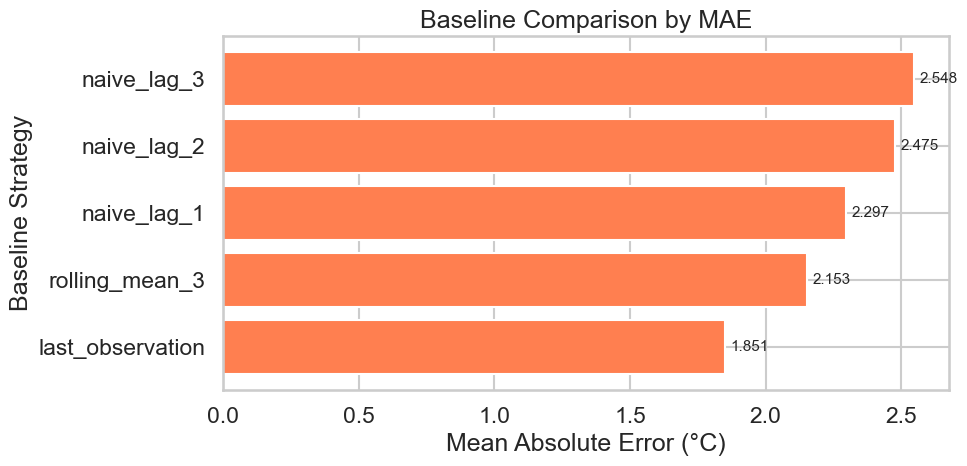

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
baseline_plot = baseline_results.sort_values("mae", ascending=True)

ax.barh(baseline_plot["model"], baseline_plot["mae"], color="coral")
ax.set_title("Baseline Comparison by MAE")
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("Baseline Strategy")

for i, v in enumerate(baseline_plot["mae"]):
    ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation

The baseline section establishes the minimum performance threshold that a more complex model must beat to justify its added complexity.  
Here, the `last_observation` baseline is notably stronger than the lag-only alternatives, which suggests strong short-term persistence in the temperature series.

## 4. Random Forest comparison across feature blocks

Random Forest was used as the main supervised benchmark because it is well suited to tabular data, captures non-linear interactions, is robust to mixed feature scales, and works well with engineered temporal features.

The feature-block experiment below was used to test whether performance improves when moving from:
- temporal core only,
- temporal + meteorology,
- temporal + meteorology + geography,
- full feature set including air quality.

This staged comparison is more informative than training on all features at once, because it shows **where** the predictive gains actually come from.


In [40]:
ml_results

,feature_set,n_features,model,mae,rmse,r2,mape,best_params
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl..."
1,C_temporal_meteorology_geography,29,RandomForestRegressor,1.754461,2.553303,0.947607,55.453987,NaN
2,B_temporal_meteorology,27,RandomForestRegressor,1.757000,2.566012,0.947085,55.289049,NaN
3,D_full,37,RandomForestRegressor,1.759364,2.569779,0.946929,55.047383,NaN
4,A_temporal_core,18,RandomForestRegressor,1.799388,2.633394,0.944269,54.870132,NaN


## Why the tuning strategy looks like this

The Random Forest experiment was organized in two stages:

1. **Feature-block screening with untuned models** to identify the most promising configuration without adding unnecessary tuning cost early on.
2. **Targeted tuning on the winning block** using `RandomizedSearchCV` with `TimeSeriesSplit(n_splits=3)`.

This was a deliberate choice.  
A full grid search would be more exhaustive, but also more expensive and not necessarily more informative for this stage of the project.  
`RandomizedSearchCV` provides a practical compromise: it explores a meaningful hyperparameter space efficiently, while `TimeSeriesSplit` keeps the validation process aligned with the forecasting structure of the problem.


In [41]:
comparison_plot = ml_results.copy()

label_map = {
    "A_temporal_core": "A | Temporal core",
    "B_temporal_meteorology": "B | Temporal + meteorology",
    "C_temporal_meteorology_geography": "C | Temporal + meteorology + geography",
    "D_full": "D | Full feature set",
}

comparison_plot["feature_label"] = comparison_plot["feature_set"].map(label_map)
comparison_plot["model_label"] = comparison_plot["model"].replace(
    {
        "RandomForestRegressor": "Random Forest",
        "RandomForestRegressor_tuned": "Random Forest (tuned)",
    }
)

comparison_plot["label"] = comparison_plot["feature_label"] + " | " + comparison_plot["model_label"]
comparison_plot

,feature_set,n_features,model,mae,rmse,r2,mape,best_params,feature_label,model_label,label
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl...",C | Temporal + meteorology + geography,Random Forest (tuned),C | Temporal + meteorology + geography | Rando...
1,C_temporal_meteorology_geography,29,RandomForestRegressor,1.754461,2.553303,0.947607,55.453987,NaN,C | Temporal + meteorology + geography,Random Forest,C | Temporal + meteorology + geography | Rando...
2,B_temporal_meteorology,27,RandomForestRegressor,1.757000,2.566012,0.947085,55.289049,NaN,B | Temporal + meteorology,Random Forest,B | Temporal + meteorology | Random Forest
3,D_full,37,RandomForestRegressor,1.759364,2.569779,0.946929,55.047383,NaN,D | Full feature set,Random Forest,D | Full feature set | Random Forest
4,A_temporal_core,18,RandomForestRegressor,1.799388,2.633394,0.944269,54.870132,NaN,A | Temporal core,Random Forest,A | Temporal core | Random Forest


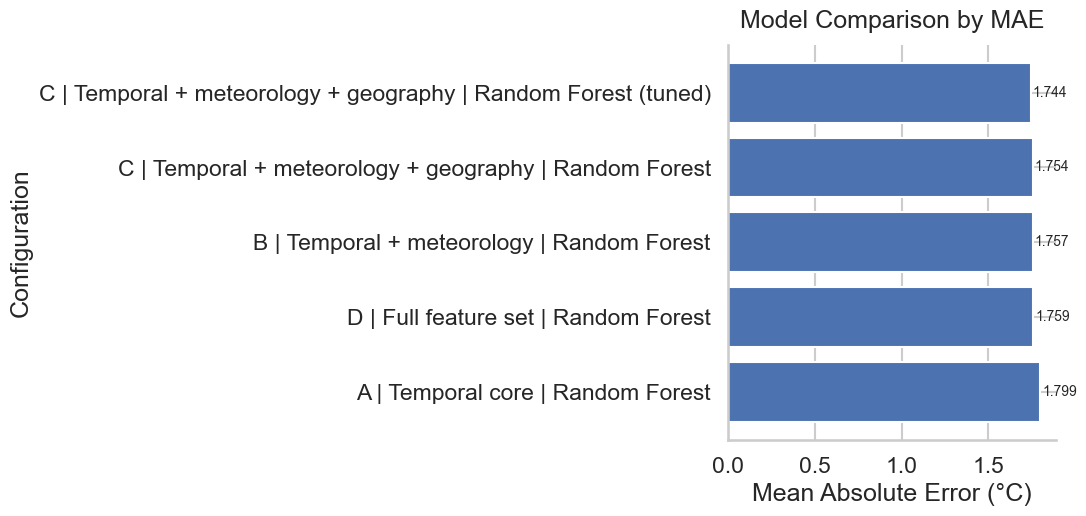

In [42]:
plot_mae = comparison_plot.sort_values("mae", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot_mae["label"], plot_mae["mae"])

ax.set_title("Model Comparison by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("Configuration")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

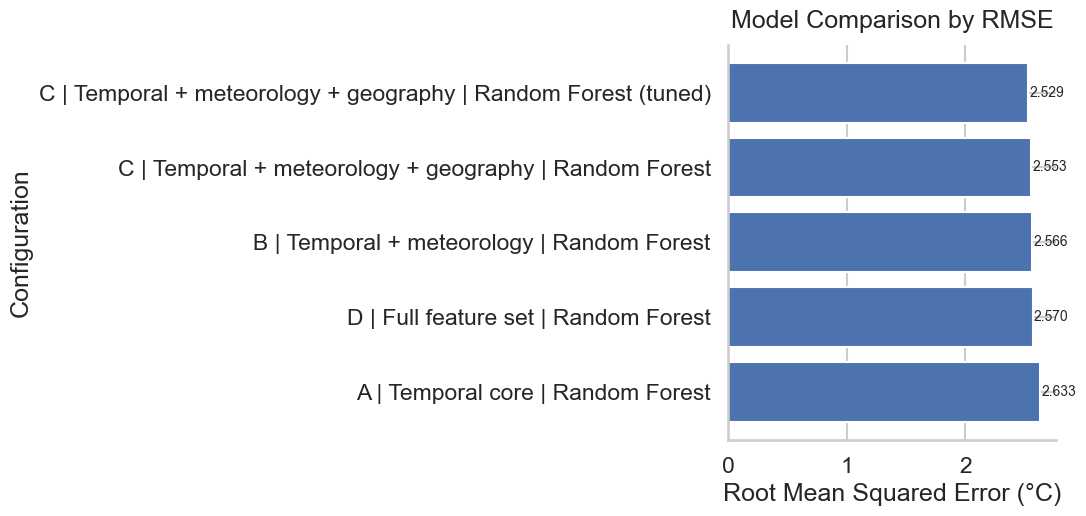

In [43]:
plot_rmse = comparison_plot.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot_rmse["label"], plot_rmse["rmse"])

ax.set_title("Model Comparison by RMSE", pad=12)
ax.set_xlabel("Root Mean Squared Error (°C)")
ax.set_ylabel("Configuration")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [44]:
family_summary_df = pd.DataFrame(
    [
        {
            "approach": "Best baseline",
            "model_family": "Baseline",
            "configuration": best_baseline["model"],
            "feature_set": "-",
            "mae": best_baseline["mae"],
            "rmse": best_baseline["rmse"],
            "r2": best_baseline["r2"],
        },
        {
            "approach": "Best Random Forest",
            "model_family": "Random Forest",
            "configuration": best_tuned_rf["model"],
            "feature_set": best_tuned_rf["feature_set"],
            "mae": best_tuned_rf["mae"],
            "rmse": best_tuned_rf["rmse"],
            "r2": best_tuned_rf["r2"],
        },
        {
            "approach": "Best HistGradientBoosting",
            "model_family": "HistGradientBoosting",
            "configuration": best_tuned_hgb["model"],
            "feature_set": best_tuned_hgb["feature_set"],
            "mae": best_tuned_hgb["mae"],
            "rmse": best_tuned_hgb["rmse"],
            "r2": best_tuned_hgb["r2"],
        },
    ]
).sort_values(["mae", "rmse"]).reset_index(drop=True)

family_summary_df

,approach,model_family,configuration,feature_set,mae,rmse,r2
0,Best Random Forest,Random Forest,RandomForestRegressor_tuned,C_temporal_meteorology_geography,1.743873,2.528803,0.948608
1,Best HistGradientBoosting,HistGradientBoosting,HistGradientBoostingRegressor_tuned,D_full,1.779385,2.625829,0.944589
2,Best baseline,Baseline,last_observation,-,1.851315,2.725922,0.940315


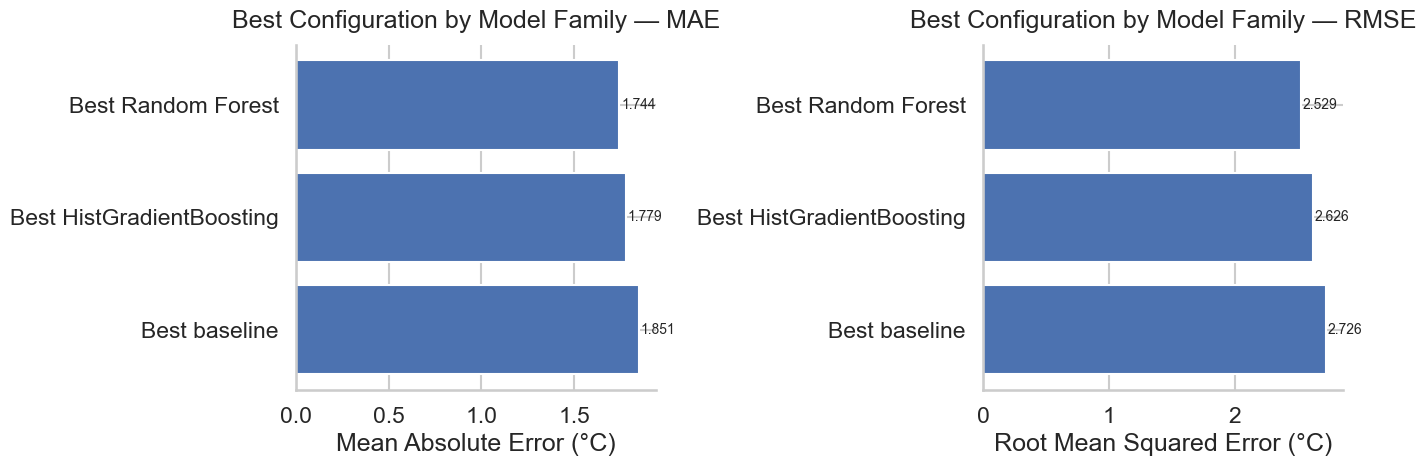

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_mae = family_summary_df.sort_values("mae", ascending=True)
bars_mae = axes[0].barh(plot_mae["approach"], plot_mae["mae"])
axes[0].set_title("Best Configuration by Model Family — MAE", pad=12)
axes[0].set_xlabel("Mean Absolute Error (°C)")
axes[0].set_ylabel("")
axes[0].invert_yaxis()

for bar in bars_mae:
    width = bar.get_width()
    axes[0].text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=10)

plot_rmse = family_summary_df.sort_values("rmse", ascending=True)
bars_rmse = axes[1].barh(plot_rmse["approach"], plot_rmse["rmse"])
axes[1].set_title("Best Configuration by Model Family — RMSE", pad=12)
axes[1].set_xlabel("Root Mean Squared Error (°C)")
axes[1].set_ylabel("")
axes[1].invert_yaxis()

for bar in bars_rmse:
    width = bar.get_width()
    axes[1].text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=10)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [46]:
feature_block_results = ml_results[ml_results["model"] == "RandomForestRegressor"].sort_values("mae").reset_index(drop=True)

block_summary = f'''
### Initial finding

Inside the Random Forest family, **{feature_block_results.iloc[0]["feature_set"]}** was the strongest untuned feature block with **MAE = {feature_block_results.iloc[0]["mae"]:.3f}**.  
That suggests meteorological and geographic context added useful signal beyond the temporal-only setup, while the full feature block did not improve enough to become the best Random Forest configuration.

The chart above also places this result in context: both machine learning families improved on the best baseline, but the tuned **Random Forest** remained the strongest overall model.
'''
display(Markdown(block_summary))


### Initial finding

Inside the Random Forest family, **C_temporal_meteorology_geography** was the strongest untuned feature block with **MAE = 1.754**.  
That suggests meteorological and geographic context added useful signal beyond the temporal-only setup, while the full feature block did not improve enough to become the best Random Forest configuration.

The chart above also places this result in context: both machine learning families improved on the best baseline, but the tuned **Random Forest** remained the strongest overall model.


## 5. Additional model benchmark: HistGradientBoostingRegressor

To make the model-selection step more credible, a second ensemble family was tested under the same general protocol:
- the same chronological holdout,
- the same feature-block structure,
- and the same time-aware tuning logic.

`HistGradientBoostingRegressor` is a strong benchmark for structured data because it can capture non-linear interactions efficiently and often performs well on medium-to-large tabular datasets.  
The goal here is not to add another model for the sake of variety. It is to check whether a boosting-based ensemble can actually outperform the bagging-based Random Forest in this forecasting setup.


In [47]:
hgb_results

,feature_set,n_features,model,mae,rmse,r2,mape,best_params
0,D_full,37,HistGradientBoostingRegressor_tuned,1.779385,2.625829,0.944589,55.722904,"{'model__min_samples_leaf': 30, 'model__max_it..."
1,D_full,37,HistGradientBoostingRegressor,1.781893,2.627939,0.944500,55.612498,NaN
2,C_temporal_meteorology_geography,29,HistGradientBoostingRegressor,1.782995,2.627640,0.944512,55.895401,NaN
3,B_temporal_meteorology,27,HistGradientBoostingRegressor,1.785855,2.643283,0.943850,56.308090,NaN
4,A_temporal_core,18,HistGradientBoostingRegressor,1.819506,2.717043,0.940672,56.314704,NaN


In [48]:
best_hgb_untuned = (
    hgb_results[hgb_results["model"] == "HistGradientBoostingRegressor"]
    .sort_values(["mae", "rmse"])
    .iloc[0]
    .copy()
)

hgb_label_map = {
    "A_temporal_core": "A | Temporal core",
    "B_temporal_meteorology": "B | Temporal + meteorology",
    "C_temporal_meteorology_geography": "C | Temporal + meteorology + geography",
    "D_full": "D | Full feature set",
}

hgb_plot_df = hgb_results[hgb_results["model"] == "HistGradientBoostingRegressor"].copy()
hgb_plot_df["feature_label"] = hgb_plot_df["feature_set"].map(hgb_label_map)

final_model_selection_df = pd.DataFrame(
    [
        {
            "approach": "Best baseline",
            "model_family": "Baseline",
            "configuration": best_baseline["model"],
            "feature_set": "-",
            "mae": best_baseline["mae"],
            "rmse": best_baseline["rmse"],
            "r2": best_baseline["r2"],
        },
        {
            "approach": "Random Forest (tuned)",
            "model_family": "Random Forest",
            "configuration": best_tuned_rf["model"],
            "feature_set": best_tuned_rf["feature_set"],
            "mae": best_tuned_rf["mae"],
            "rmse": best_tuned_rf["rmse"],
            "r2": best_tuned_rf["r2"],
        },
        {
            "approach": "HistGradientBoosting (tuned)",
            "model_family": "HistGradientBoosting",
            "configuration": best_tuned_hgb["model"],
            "feature_set": best_tuned_hgb["feature_set"],
            "mae": best_tuned_hgb["mae"],
            "rmse": best_tuned_hgb["rmse"],
            "r2": best_tuned_hgb["r2"],
        },
    ]
).sort_values(["mae", "rmse"]).reset_index(drop=True)

final_model_selection_df

,approach,model_family,configuration,feature_set,mae,rmse,r2
0,Random Forest (tuned),Random Forest,RandomForestRegressor_tuned,C_temporal_meteorology_geography,1.743873,2.528803,0.948608
1,HistGradientBoosting (tuned),HistGradientBoosting,HistGradientBoostingRegressor_tuned,D_full,1.779385,2.625829,0.944589
2,Best baseline,Baseline,last_observation,-,1.851315,2.725922,0.940315


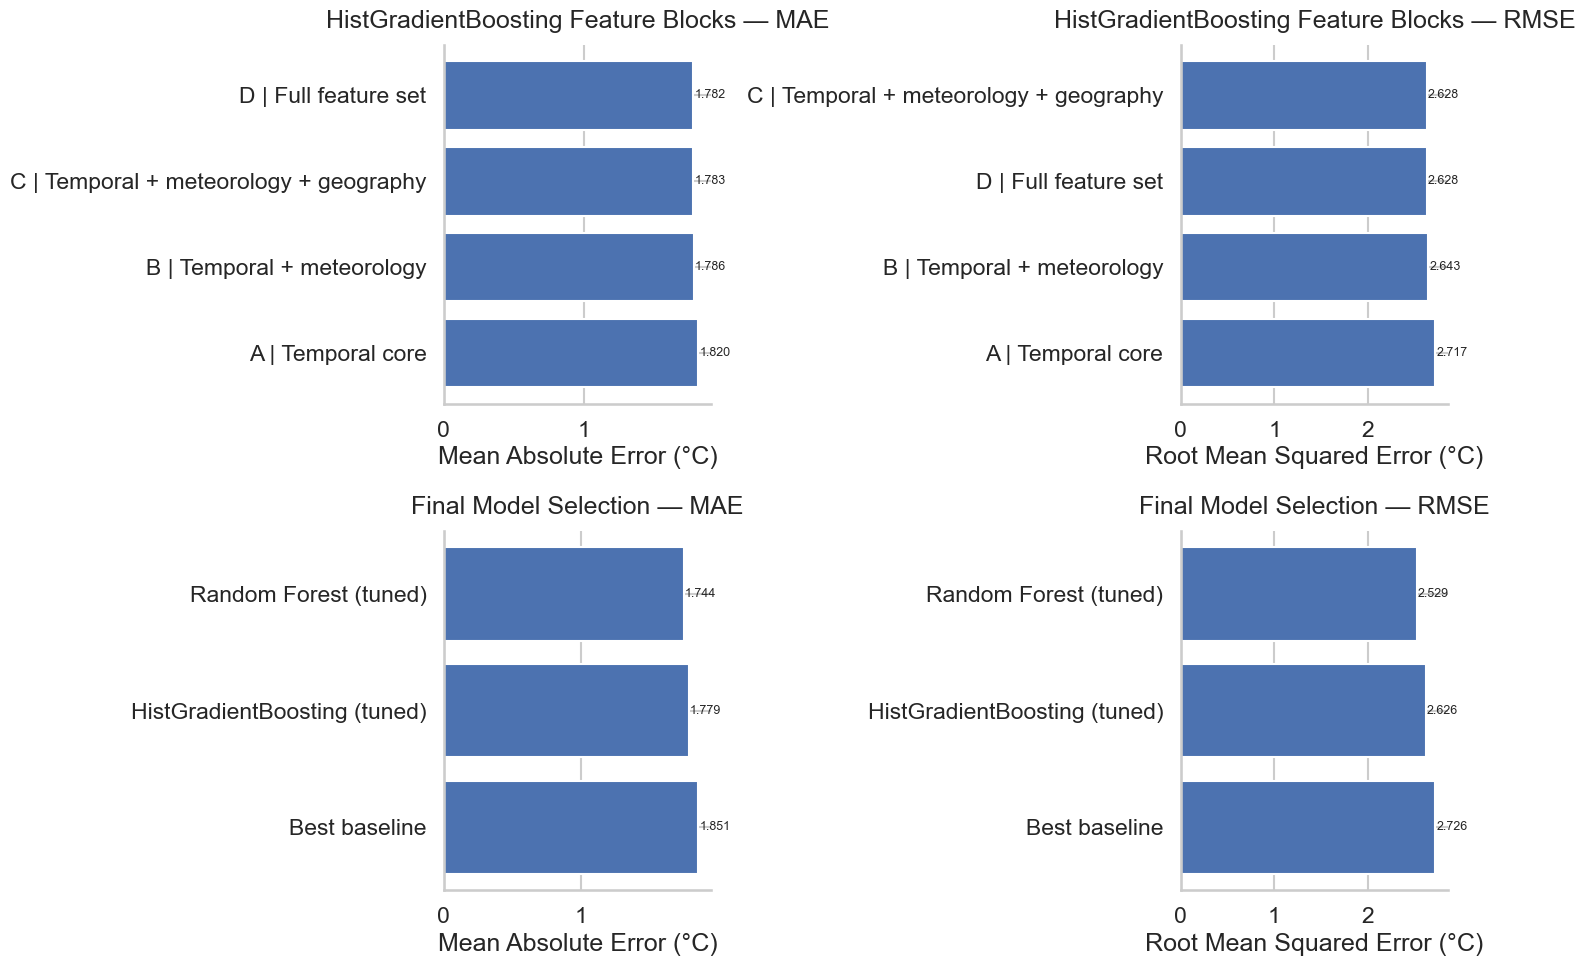

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_hgb_mae = hgb_plot_df.sort_values("mae", ascending=True)
bars_hgb_mae = axes[0, 0].barh(plot_hgb_mae["feature_label"], plot_hgb_mae["mae"])
axes[0, 0].set_title("HistGradientBoosting Feature Blocks — MAE", pad=12)
axes[0, 0].set_xlabel("Mean Absolute Error (°C)")
axes[0, 0].set_ylabel("")
axes[0, 0].invert_yaxis()
for bar in bars_hgb_mae:
    width = bar.get_width()
    axes[0, 0].text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

plot_hgb_rmse = hgb_plot_df.sort_values("rmse", ascending=True)
bars_hgb_rmse = axes[0, 1].barh(plot_hgb_rmse["feature_label"], plot_hgb_rmse["rmse"])
axes[0, 1].set_title("HistGradientBoosting Feature Blocks — RMSE", pad=12)
axes[0, 1].set_xlabel("Root Mean Squared Error (°C)")
axes[0, 1].set_ylabel("")
axes[0, 1].invert_yaxis()
for bar in bars_hgb_rmse:
    width = bar.get_width()
    axes[0, 1].text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

plot_final_mae = final_model_selection_df.sort_values("mae", ascending=True)
bars_final_mae = axes[1, 0].barh(plot_final_mae["approach"], plot_final_mae["mae"])
axes[1, 0].set_title("Final Model Selection — MAE", pad=12)
axes[1, 0].set_xlabel("Mean Absolute Error (°C)")
axes[1, 0].set_ylabel("")
axes[1, 0].invert_yaxis()
for bar in bars_final_mae:
    width = bar.get_width()
    axes[1, 0].text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

plot_final_rmse = final_model_selection_df.sort_values("rmse", ascending=True)
bars_final_rmse = axes[1, 1].barh(plot_final_rmse["approach"], plot_final_rmse["rmse"])
axes[1, 1].set_title("Final Model Selection — RMSE", pad=12)
axes[1, 1].set_xlabel("Root Mean Squared Error (°C)")
axes[1, 1].set_ylabel("")
axes[1, 1].invert_yaxis()
for bar in bars_final_rmse:
    width = bar.get_width()
    axes[1, 1].text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

for row in axes:
    for ax in row:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

Within the HistGradientBoosting family, the best untuned feature block was **{best_hgb_untuned["feature_set"]}**.  
That means the boosting-based model responded to feature enrichment as well, although its best-performing block was not enough to beat the tuned Random Forest in the final comparison.

The final charts make the selection step clearer: the project does not compare only a baseline against Random Forest.  
It compares a strong persistence baseline, a tuned bagging-based ensemble, and a tuned boosting-based ensemble under the same temporal evaluation logic. On that basis, the tuned **Random Forest** remained the strongest final model.


## 6. Permutation importance of the selected final model

The purpose of this section is not to claim causality.  
Instead, it identifies which variables the **selected tuned Random Forest** relied on most when making predictions on the held-out test set.

In [50]:
top_importance = importance_df.head(15).copy()
top_importance

,feature,importance_mean,importance_std,feature_set
0,temperature_celsius,3.836215,0.014983,C_temporal_meteorology_geography
1,feels_like_celsius,2.855105,0.022283,C_temporal_meteorology_geography
2,temp_roll_mean_3,0.514289,0.007060,C_temporal_meteorology_geography
3,temp_lag_3,0.074038,0.002052,C_temporal_meteorology_geography
4,latitude,0.062531,0.002296,C_temporal_meteorology_geography
5,temp_lag_1,0.037366,0.001722,C_temporal_meteorology_geography
6,temp_lag_2,0.036211,0.001528,C_temporal_meteorology_geography
7,pressure_mb,0.025009,0.001399,C_temporal_meteorology_geography
8,humidity,0.012265,0.000720,C_temporal_meteorology_geography
9,uv_index,0.004964,0.000521,C_temporal_meteorology_geography


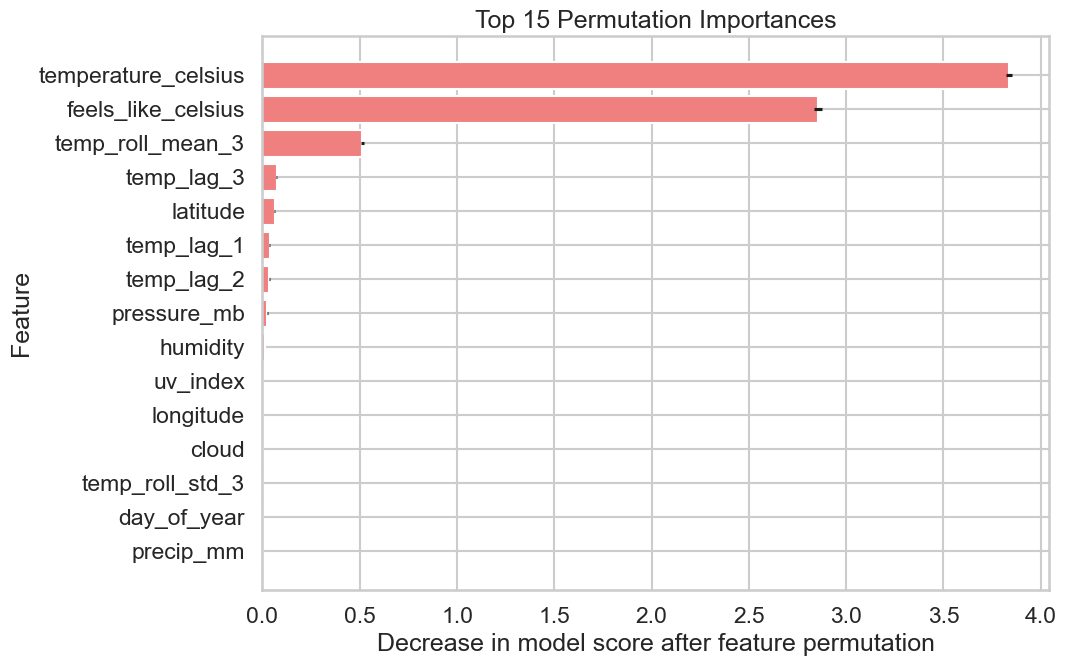

In [51]:
top_importance_plot = top_importance.sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    top_importance_plot["feature"],
    top_importance_plot["importance_mean"],
    xerr=top_importance_plot["importance_std"],
    color="lightcoral",
)
ax.set_title("Top 15 Permutation Importances")
ax.set_xlabel("Decrease in model score after feature permutation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [52]:
top3 = importance_df.head(3)["feature"].tolist()
imp_text = f'''
### Initial finding

The importance analysis shows a clear hierarchy. The top contributors were **{top3[0]}**, **{top3[1]}**, and **{top3[2]}**.  
This supports the earlier correlation analysis: short-term prediction is driven mainly by recent thermal information, with additional gains from contextual variables rather than from the full environmental block.
'''
display(Markdown(imp_text))


### Initial finding

The importance analysis shows a clear hierarchy. The top contributors were **temperature_celsius**, **feels_like_celsius**, and **temp_roll_mean_3**.  
This supports the earlier correlation analysis: short-term prediction is driven mainly by recent thermal information, with additional gains from contextual variables rather than from the full environmental block.


## 7. Prediction error analysis for the selected final model

In [53]:
best_feature_set = best_tuned_rf["feature_set"]
best_preds = ml_predictions[ml_predictions["feature_set"] == best_feature_set].copy()

best_preds["error"] = best_preds["target_temperature_next"] - best_preds["prediction"]
best_preds["absolute_error"] = best_preds["error"].abs()

best_preds.head()


,location_name,country,last_updated,target_temperature_next,feature_set,prediction,error,absolute_error
52134,Madrid,Spain,2025-11-04 08:45:00,12.3,C_temporal_meteorology_geography,9.021127,3.278873,3.278873
52135,Warsaw,Poland,2025-11-04 09:00:00,6.1,C_temporal_meteorology_geography,8.048903,-1.948903,1.948903
52136,'S-Gravenbrakel,Belgium,2025-11-04 09:00:00,12.3,C_temporal_meteorology_geography,10.653892,1.646108,1.646108
52137,Andorra La Vella,Andorra,2025-11-04 09:00:00,5.5,C_temporal_meteorology_geography,6.791142,-1.291142,1.291142
52138,Amsterdam,Netherlands,2025-11-04 09:00:00,12.3,C_temporal_meteorology_geography,11.174860,1.125140,1.125140


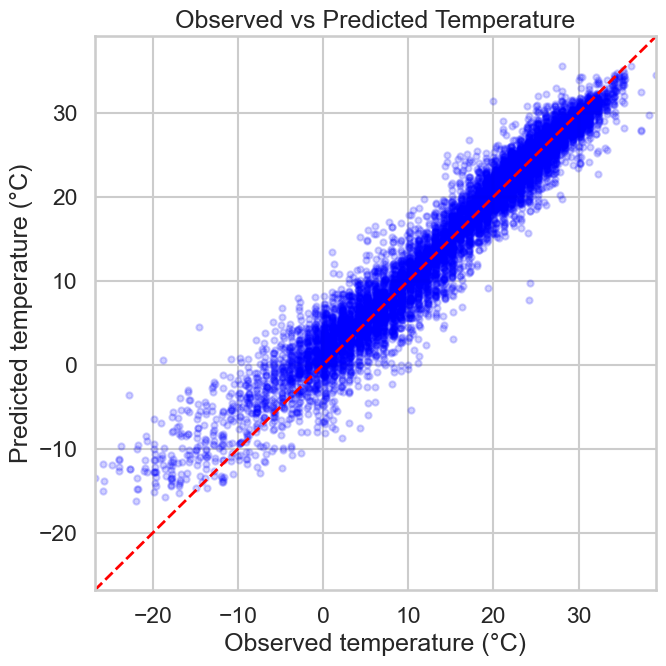

In [54]:
sample_n = min(len(best_preds), 12000)
plot_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

obs_min = min(plot_sample["target_temperature_next"].min(), plot_sample["prediction"].min())
obs_max = max(plot_sample["target_temperature_next"].max(), plot_sample["prediction"].max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_sample["target_temperature_next"], plot_sample["prediction"], c="blue", alpha=0.18, s=20)
ax.plot([obs_min, obs_max], [obs_min, obs_max], linestyle="--", c="red", linewidth=2)
ax.set_title("Observed vs Predicted Temperature")
ax.set_xlabel("Observed temperature (°C)")
ax.set_ylabel("Predicted temperature (°C)")
ax.set_xlim(obs_min, obs_max)
ax.set_ylim(obs_min, obs_max)
plt.tight_layout()
plt.show()

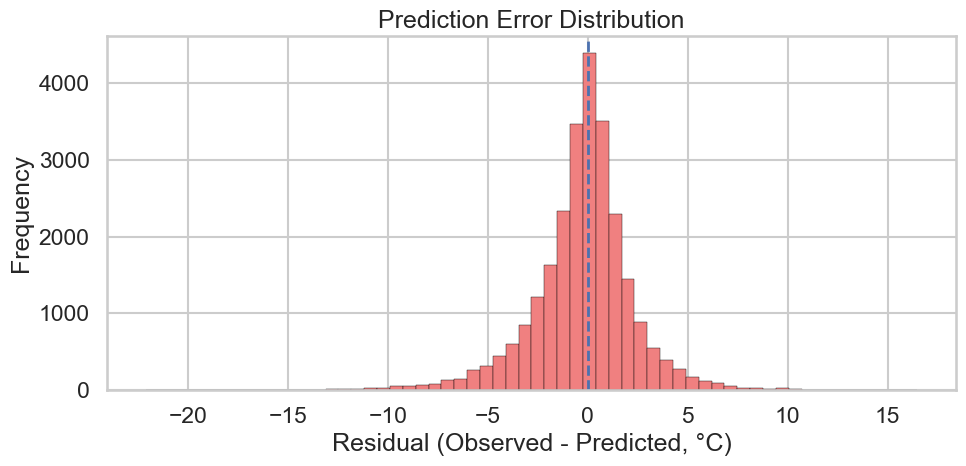

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_preds["error"], bins=60, edgecolor="black", color="lightcoral",linewidth=0.3)
ax.axvline(0, linestyle="--", linewidth=2)
ax.set_title("Prediction Error Distribution")
ax.set_xlabel("Residual (Observed - Predicted, °C)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

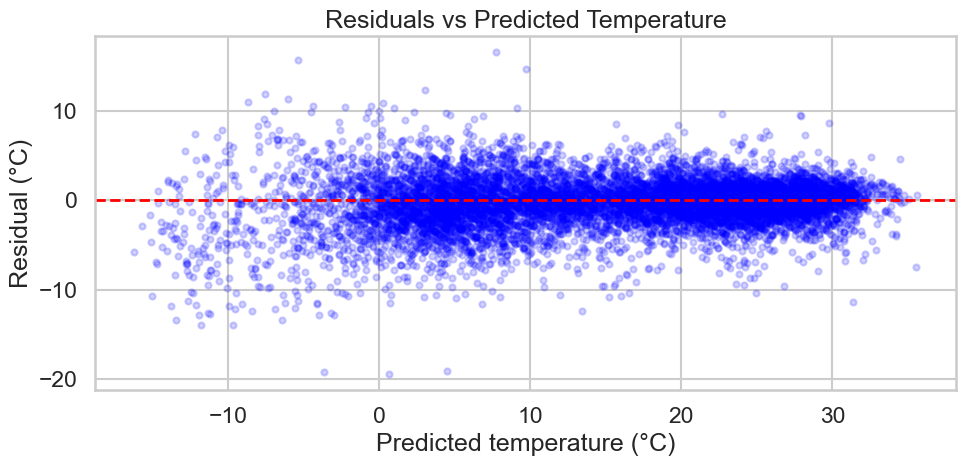

In [56]:
sample_n = min(len(best_preds), 12000)
resid_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(resid_sample["prediction"], resid_sample["error"], c="blue", alpha=0.18, s=20)
ax.axhline(0, linestyle="--", c="red", linewidth=2)
ax.set_title("Residuals vs Predicted Temperature")
ax.set_xlabel("Predicted temperature (°C)")
ax.set_ylabel("Residual (°C)")
plt.tight_layout()
plt.show()

In [57]:
best_preds["absolute_error"] = best_preds["error"].abs()

error_summary = (
    best_preds["absolute_error"]
    .describe(percentiles=[0.5, 0.9, 0.95])
    [["mean", "50%", "90%", "95%", "max"]]
    .rename(
        {
            "mean": "mean_abs_error",
            "50%": "median_abs_error",
            "90%": "p90_abs_error",
            "95%": "p95_abs_error",
            "max": "max_abs_error",
        }
    )
)

error_summary.to_frame(name="value")

,value
mean_abs_error,1.754461
median_abs_error,1.171201
p90_abs_error,4.065878
p95_abs_error,5.416794
max_abs_error,22.134074


## 8. Advanced error analysis by location

Global metrics are useful, but they can hide local performance differences.  
This section evaluates how error varies across cities to identify where the model is most reliable and where forecasting remains more difficult.

In [58]:
location_error_df = (
    best_preds.groupby(["location_name", "country"], as_index=False)
    .agg(
        n_predictions=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda s: np.sqrt(np.mean(np.square(s)))),
        mean_error=("error", "mean"),
    )
)

location_error_df = location_error_df.sort_values(["mae", "rmse"], ascending=[True, True]).reset_index(drop=True)
location_error_df.head(10)

,location_name,country,n_predictions,mae,rmse,mean_error
0,Roseau,Dominica,132,0.253764,0.309782,0.069408
1,Dhidhdhoo,Maldives,134,0.327640,0.431170,-0.156751
2,Tarawa,Kiribati,135,0.374909,0.465156,0.104746
3,Lima,Peru,133,0.430026,0.538831,0.084135
4,Yamoussoukro,Cote d'Ivoire,133,0.487544,0.695401,-0.161539
5,Mogadishu,Somalia,133,0.497065,0.648485,0.107582
6,Monrovia,Liberia,133,0.500299,0.713449,-0.012175
7,Djibouti,Djibouti,134,0.500831,0.632262,-0.091487
8,Paramaribo,Suriname,132,0.577143,0.792130,-0.113206
9,Bras,Brazil,133,0.615540,0.843967,-0.029507


In [59]:
top_best_locations = (
    location_error_df[location_error_df["n_predictions"] >= 30]
    .sort_values(["mae", "rmse"], ascending=[True, True])
    .head(10)
)

top_worst_locations = (
    location_error_df[location_error_df["n_predictions"] >= 30]
    .sort_values(["mae", "rmse"], ascending=[False, False])
    .head(10)
)

display(top_best_locations)
display(top_worst_locations)

,location_name,country,n_predictions,mae,rmse,mean_error
0,Roseau,Dominica,132,0.253764,0.309782,0.069408
1,Dhidhdhoo,Maldives,134,0.327640,0.431170,-0.156751
2,Tarawa,Kiribati,135,0.374909,0.465156,0.104746
3,Lima,Peru,133,0.430026,0.538831,0.084135
4,Yamoussoukro,Cote d'Ivoire,133,0.487544,0.695401,-0.161539
5,Mogadishu,Somalia,133,0.497065,0.648485,0.107582
6,Monrovia,Liberia,133,0.500299,0.713449,-0.012175
7,Djibouti,Djibouti,134,0.500831,0.632262,-0.091487
8,Paramaribo,Suriname,132,0.577143,0.792130,-0.113206
9,Bras,Brazil,133,0.615540,0.843967,-0.029507


,location_name,country,n_predictions,mae,rmse,mean_error
201,Chi-Chi-Erh,Russia,32,7.342283,9.136284,-6.836793
199,Astana,Kazakhstan,134,4.899215,6.485592,-2.614771
198,Ottawa,Canada,134,4.521040,5.661357,-1.650700
197,Canberra,Australia,134,4.221791,5.182182,0.967932
196,Minsk,Belarus,133,4.024579,5.353998,-2.336509
195,Oslo,Norway,133,3.824818,5.052745,-0.674156
194,Helsinki,Finland,134,3.727471,4.792805,-1.614812
193,Ulaanbaatar,Mongolia,135,3.713931,4.983483,-2.977160
192,Vilnius,Lithuania,134,3.336975,4.375031,-1.680944
191,Moscow,Russia,134,3.328761,4.547924,-2.077207


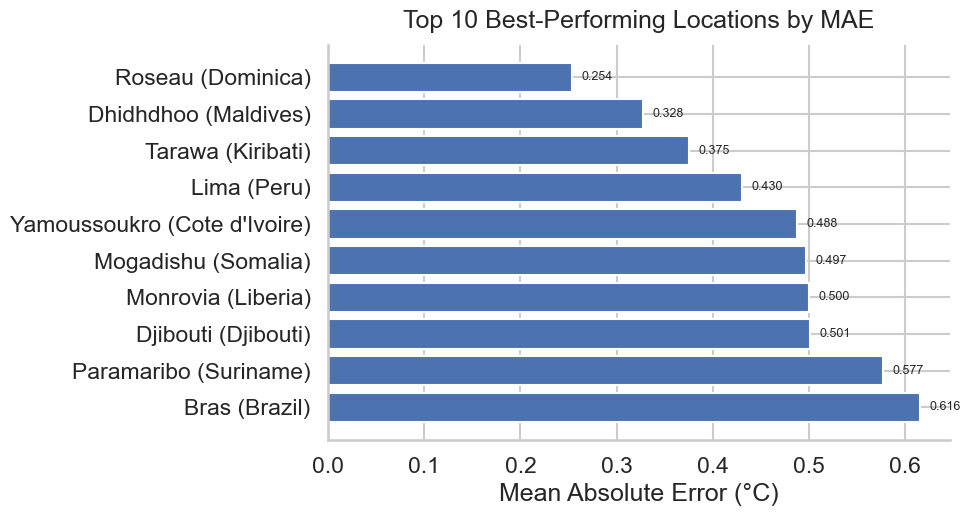

In [60]:
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = top_best_locations["location_name"] + " (" + top_best_locations["country"] + ")"
bars = ax.barh(labels, top_best_locations["mae"])

ax.set_title("Top 10 Best-Performing Locations by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

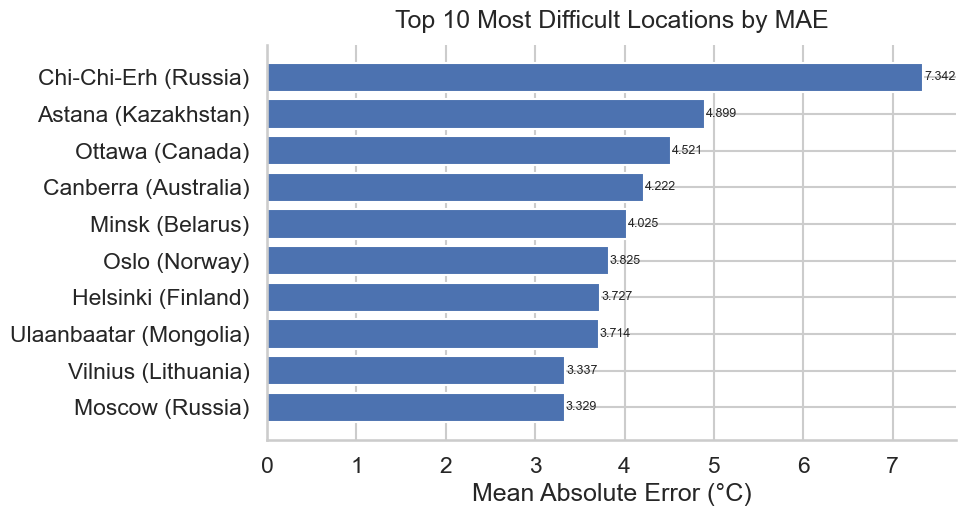

In [61]:
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = top_worst_locations["location_name"] + " (" + top_worst_locations["country"] + ")"
bars = ax.barh(labels, top_worst_locations["mae"])

ax.set_title("Top 10 Most Difficult Locations by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

Forecasting quality is not uniform across locations.  
Some cities exhibit consistently low error, while others remain more difficult, which is expected in a global dataset combining different local climates, seasonal regimes, and short-term variability patterns.

## 9. Extreme errors and difficult cases

Average error metrics do not explain where the model fails most.  
Inspecting the largest residuals helps identify difficult moments and assess whether abrupt temperature changes are harder to predict than stable trajectories.

In [62]:
feature_lookup = (
    feature_df[
        ["location_name", "country", "last_updated", "temperature_celsius", "latitude", "longitude"]
    ]
    .drop_duplicates(subset=["location_name", "country", "last_updated"])
    .copy()
)

best_preds = best_preds.merge(
    feature_lookup,
    on=["location_name", "country", "last_updated"],
    how="left",
    validate="many_to_one",
)

best_preds["temp_change"] = best_preds["target_temperature_next"] - best_preds["temperature_celsius"]
best_preds[["location_name", "last_updated", "temperature_celsius", "temp_change"]].head()


,location_name,last_updated,temperature_celsius,temp_change
0,Madrid,2025-11-04 08:45:00,7.3,5.0
1,Warsaw,2025-11-04 09:00:00,7.4,-1.3
2,'S-Gravenbrakel,2025-11-04 09:00:00,12.1,0.2
3,Andorra La Vella,2025-11-04 09:00:00,6.3,-0.8
4,Amsterdam,2025-11-04 09:00:00,13.4,-1.1


In [63]:
hard_cases = best_preds.sort_values("absolute_error", ascending=False).copy()

hard_case_columns = [
    "location_name",
    "country",
    "last_updated",
    "temperature_celsius",
    "target_temperature_next",
    "prediction",
    "error",
    "absolute_error",
    "temp_change",
]

hard_cases[hard_case_columns].head(15)

,location_name,country,last_updated,temperature_celsius,target_temperature_next,prediction,error,absolute_error,temp_change
9273,Chi-Chi-Erh,Russia,2025-12-21 14:00:00,-16.8,-14.0,8.134074,-22.134074,22.134074,2.8
9857,Chi-Chi-Erh,Russia,2025-12-24 14:00:00,-14.8,-18.8,0.640889,-19.440889,19.440889,-4.0
10041,Astana,Kazakhstan,2025-12-25 12:00:00,-3.6,-22.8,-3.629125,-19.170875,19.170875,-19.2
6724,Astana,Kazakhstan,2025-12-08 12:15:00,0.1,-18.9,0.254217,-19.154217,19.154217,-19.0
12525,Bogot,Bulgaria,2026-01-07 09:15:00,4.4,-14.6,4.482285,-19.082285,19.082285,-19.0
9664,Chi-Chi-Erh,Russia,2025-12-23 14:15:00,-14.0,-14.8,3.822559,-18.622559,18.622559,-0.8
5801,Ottawa,Canada,2025-12-04 02:00:00,-0.7,-21.0,-3.218307,-17.781693,17.781693,-20.3
21048,Oslo,Norway,2026-02-21 07:45:00,4.2,-13.9,3.767760,-17.667760,17.667760,-18.1
20357,Ashgabat,Turkmenistan,2026-02-17 11:45:00,6.2,24.2,7.707705,16.492295,16.492295,18.0
24003,Astana,Kazakhstan,2026-03-08 11:45:00,0.5,-15.9,0.017263,-15.917263,15.917263,-16.4


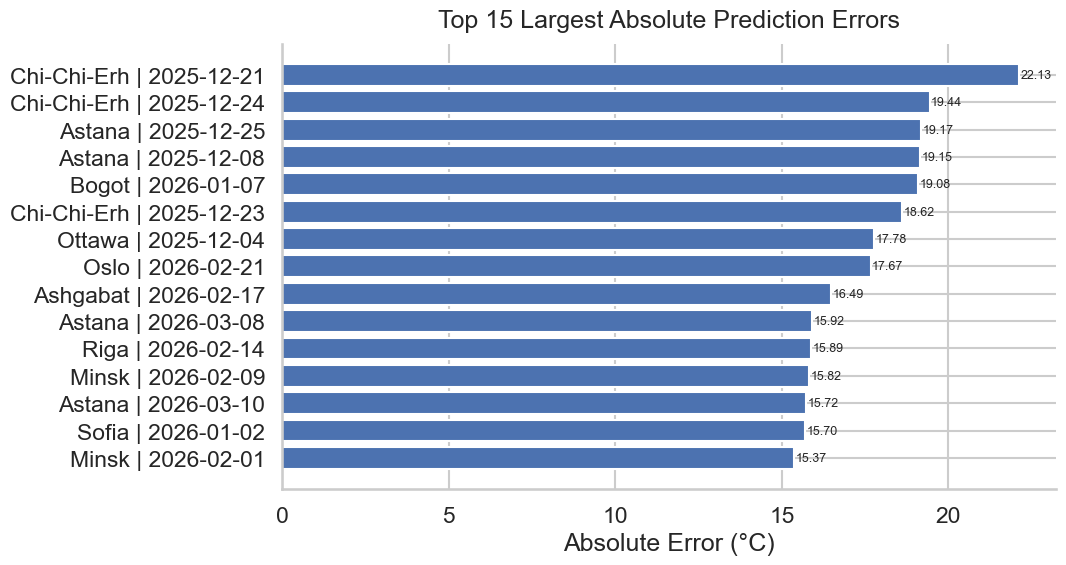

In [64]:
top_hard_cases = hard_cases.head(15).copy()
top_hard_cases["label"] = (
    top_hard_cases["location_name"]
    + " | "
    + top_hard_cases["last_updated"].astype(str).str[:10]
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_hard_cases["label"], top_hard_cases["absolute_error"])

ax.set_title("Top 15 Largest Absolute Prediction Errors", pad=12)
ax.set_xlabel("Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height() / 2, f"{width:.2f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

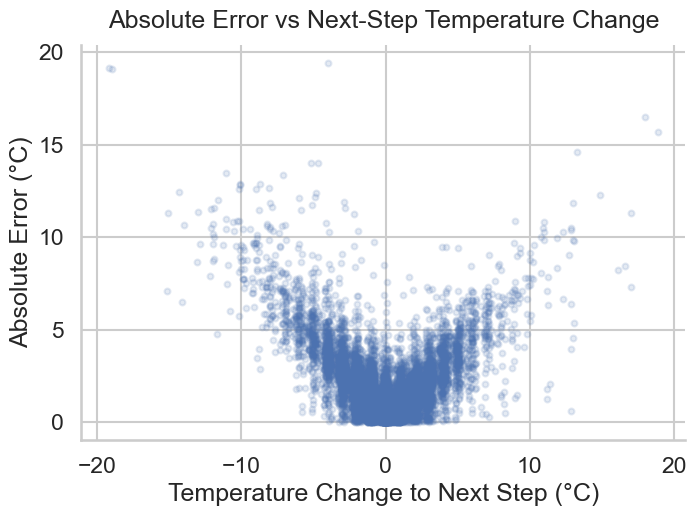

In [65]:
sample_n = min(len(best_preds), 12000)
change_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(change_sample["temp_change"], change_sample["absolute_error"], alpha=0.15, s=18)

ax.set_title("Absolute Error vs Next-Step Temperature Change", pad=12)
ax.set_xlabel("Temperature Change to Next Step (°C)")
ax.set_ylabel("Absolute Error (°C)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

The largest errors tend to appear in more volatile transitions, where the next-step temperature changes more abruptly.  
This is consistent with the earlier finding that recent thermal history is the dominant predictive signal: the model is strongest when short-term continuity holds and weaker when the local trajectory changes sharply.

## 10. Geographic performance patterns

Because geographic variables improved performance in the best feature block, it is useful to inspect whether error varies systematically across broad spatial bands.


In [66]:
best_preds["latitude_band"] = pd.cut(
    best_preds["latitude"],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=["-90 to -60", "-60 to -30", "-30 to 0", "0 to 30", "30 to 60", "60 to 90"],
)

latitude_error_df = (
    best_preds.groupby("latitude_band", observed=False, as_index=False)
    .agg(
        n_predictions=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda s: np.sqrt(np.mean(np.square(s)))),
    )
)

latitude_error_df

,latitude_band,n_predictions,mae,rmse
0,-90 to -60,0,NaN,NaN
1,-60 to -30,666,2.384892,3.187932
2,-30 to 0,4947,1.239305,1.680714
3,0 to 30,10176,1.155449,1.633252
4,30 to 60,10012,2.538283,3.426593
5,60 to 90,266,3.169969,4.111431


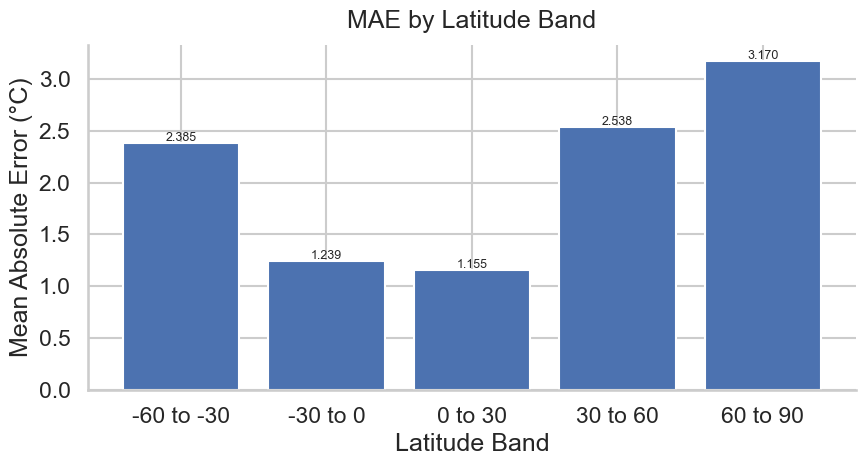

In [67]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(latitude_error_df["latitude_band"].astype(str), latitude_error_df["mae"])

ax.set_title("MAE by Latitude Band", pad=12)
ax.set_xlabel("Latitude Band")
ax.set_ylabel("Mean Absolute Error (°C)")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}", ha="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

Error differences across latitude bands help assess whether the selected model generalizes evenly across broad spatial contexts.  
If some bands show higher MAE, that suggests the forecasting pipeline is more challenged in certain climate regimes or variability patterns than in others.


## 11. Final interpretation

This final section pulls the main results together in a concise way, focusing on what was learned and why the final model choice makes sense.


In [68]:
final_text = f'''
### Final interpretation

The strongest baseline was **{best_baseline["model"]}**, which shows that short-term temperature forecasting in this dataset has strong temporal persistence.  
That is an important starting point, because it means the machine learning models had to beat a baseline that was already genuinely competitive.

Inside the Random Forest family, the best untuned feature block was **{best_untuned_rf["feature_set"]}**.  
This suggests that meteorological and geographic context added useful information beyond the temporal-only setup, while the full feature block with air-quality variables did not deliver a better trade-off inside the Random Forest comparison.

A second ensemble family, **HistGradientBoostingRegressor**, was then evaluated under the same chronological holdout and the same time-aware tuning strategy.  
It remained competitive, but it did not surpass the tuned Random Forest. The tuned **Random Forest** finished with **MAE = {best_tuned_rf["mae"]:.3f}**, **RMSE = {best_tuned_rf["rmse"]:.3f}**, and **R² = {best_tuned_rf["r2"]:.3f}**, while the tuned **HistGradientBoosting** finished with **MAE = {best_tuned_hgb["mae"]:.3f}**, **RMSE = {best_tuned_hgb["rmse"]:.3f}**, and **R² = {best_tuned_hgb["r2"]:.3f}**.

Permutation importance and the earlier correlation analysis point in the same direction: the model relies mostly on **current temperature**, **feels-like temperature**, **rolling temperature averages**, and **lagged temperatures**.  
In practice, that means recent thermal history is the main source of predictive signal, while geographic and broader meteorological variables provide incremental value.

The location-level, extreme-error, and latitude-band analyses add an important limitation.  
Performance is not uniform across the globe, and the largest errors tend to appear in sharper local temperature transitions. So the pipeline works well for short-term forecasting under relatively stable local conditions, but becomes less reliable when the next step changes more abruptly.

Taken together, the project ended with a defensible model-selection process: a strong baseline, two competitive tabular ensemble families, time-aware tuning, and post-model error analysis.  
Based on those results, the final selected model is the tuned **Random Forest** using **{best_tuned_rf["feature_set"]}**.
'''
display(Markdown(final_text))


### Final interpretation

The strongest baseline was **last_observation**, which shows that short-term temperature forecasting in this dataset has strong temporal persistence.  
That is an important starting point, because it means the machine learning models had to beat a baseline that was already genuinely competitive.

Inside the Random Forest family, the best untuned feature block was **C_temporal_meteorology_geography**.  
This suggests that meteorological and geographic context added useful information beyond the temporal-only setup, while the full feature block with air-quality variables did not deliver a better trade-off inside the Random Forest comparison.

A second ensemble family, **HistGradientBoostingRegressor**, was then evaluated under the same chronological holdout and the same time-aware tuning strategy.  
It remained competitive, but it did not surpass the tuned Random Forest. The tuned **Random Forest** finished with **MAE = 1.744**, **RMSE = 2.529**, and **R² = 0.949**, while the tuned **HistGradientBoosting** finished with **MAE = 1.779**, **RMSE = 2.626**, and **R² = 0.945**.

Permutation importance and the earlier correlation analysis point in the same direction: the model relies mostly on **current temperature**, **feels-like temperature**, **rolling temperature averages**, and **lagged temperatures**.  
In practice, that means recent thermal history is the main source of predictive signal, while geographic and broader meteorological variables provide incremental value.

The location-level, extreme-error, and latitude-band analyses add an important limitation.  
Performance is not uniform across the globe, and the largest errors tend to appear in sharper local temperature transitions. So the pipeline works well for short-term forecasting under relatively stable local conditions, but becomes less reliable when the next step changes more abruptly.

Taken together, the project ended with a defensible model-selection process: a strong baseline, two competitive tabular ensemble families, time-aware tuning, and post-model error analysis.  
Based on those results, the final selected model is the tuned **Random Forest** using **C_temporal_meteorology_geography**.
